<a href="https://colab.research.google.com/github/P2025046-SCRM/deep-learning-models-training/blob/production-score/Training_Pipeline_Binary_InceptionV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Step 1: Install missing packages

In [ ]:
%pip install split-folders

##Step 2: Splitting dataset into train/test/valid subsets:

In [ ]:
import splitfolders

# main dataset path
input_folder = "/content/drive/MyDrive/Tesis/preprocessing_data/Layer1"

# split dataset output path
output_folder = "/content/drive/MyDrive/Tesis/preprocessing_data/split_layer1"

# Split ratios

train = 0.8
valid = 0.1
test = 0.1

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=1337, # For reproducibility
    ratio=(train, valid, test),
    group_prefix=None, # In case of (img, xml) pairs
    move=False # Set to True to move files instead of copying
)

print(f"Data successfully split into {output_folder}")

Copying files: 810 files [01:37,  8.28 files/s]

Data successfully split into /content/drive/MyDrive/Tesis/preprocessing_data/split_layer1


## Step 3: Load datasets

Using Keras to load this split data

In [ ]:
import tensorflow as tf

In [ ]:
# --- 1. Define Constants ---
TRAIN_DIR = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer1/train'
VAL_DIR = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer1/val'
TEST_DIR = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer1/test'

IMG_SIZE = (299, 299) # InceptionV3 default input size
BATCH_SIZE = 32
EPOCHS = 10

# --- 2. Load the Datasets ---
# Load the raw datasets first
# Resizing will happen *in the model*.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # Test set wont be shuffled
)

# Get class names
class_names = train_dataset.class_names
print("Classes found by Keras:", class_names)

# --- 3. Optimize Data Pipelines ---
# This pre-fetches data in the background
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Found 647 files belonging to 2 classes.
Found 80 files belonging to 2 classes.
Found 83 files belonging to 2 classes.
Classes found by Keras: ['NoReciclable', 'Reciclable']


Weights to control data imbalance

In [ ]:
# --- Calculate Class Weights ---
# Class 0: NoReciclable (157 images)
# Class 1: Reciclable (653 images)
# Total: 810 images

weight_for_0 = (1 / 157) * (810 / 2.0)
weight_for_1 = (1 / 653) * (810 / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for class 0 (Non-recyclable): {weight_for_0:.2f}")
print(f"Weight for class 1 (Recyclable): {weight_for_1:.2f}")

Weight for class 0 (Non-recyclable): 2.58
Weight for class 1 (Recyclable): 0.62


## Step 4: Build the model with augmentation on the train dataset

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import Precision, Recall, AUC, F1Score

## Transfer Learning using InceptionV3

### Feature Extraction

In [ ]:
# --- 1. Define Data Augmentation Layers ---
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1),
], name="data_augmentation")

# --- 2. Define InceptionV3 Preprocessing ---
# The *specific* rescaling InceptionV3 expects
preprocess_input = tf.keras.applications.inception_v3.preprocess_input

# --- 3. Load the Base Model (InceptionV3) ---
base_model = tf.keras.applications.InceptionV3(
    include_top=False,  # Remove the final ImageNet classifier
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
    name="inceptionv3_base"
)

# --- 4. Freeze the Base Model ---
# To avoid re-training the learned ImageNet features
base_model.trainable = False

# --- 5. Chain Everything Together ---
inputs = layers.Input(shape=IMG_SIZE + (3,), name="input_layer")

# 1. Augment (Only during training)
x = data_augmentation(inputs)

# 2. Rescale (Apply InceptionV3's specific preprocessing)
x = preprocess_input(x)

# 3. Run through the frozen base model
x = base_model(x, training=False)

# 4. Add our custom classifier "head"
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(128, activation='relu', name="dense_128")(x)
x = layers.Dropout(0.2, name="dropout")(x) # Regularization
outputs = layers.Dense(1, activation='sigmoid')(x)

# 6. Create the final model
model = Model(inputs, outputs)

# --- 6. Compile the Model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    #Metrics to be tracked:
    metrics=[
        'accuracy',  # The classic percentage of correct predictions
        Precision(name='precision'), # How many positive predictions were correct
        Recall(name='recall'),       # How many positive cases did the model find
        AUC(name='auc'),              # Area Under the ROC Curve
        F1Score(name='f1_score')
    ]
)

# Let's see the full architecture
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inceptionv3_base (Functional)   │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

##Step 5: Train the model

In [ ]:
import time

print("Starting training.")

# Record the start time
start_time = time.time()

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weight
)

# Record the end time
end_time = time.time()

# Calculate the training time
training_time = end_time - start_time

print("Training complete.")
print(f"Total training time: {training_time:.2f} seconds")

Starting training.
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 210s 9s/step - accuracy: 0.6704 - auc: 0.6844 - f1_score: 0.9016 - loss: 0.6183 - precision: 0.8880 - recall: 0.6838 - val_accuracy: 0.8250 - val_auc: 0.9446 - val_f1_score: 0.8966 - val_loss: 0.4139 - val_precision: 0.9811 - val_recall: 0.8000
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.7955 - auc: 0.8936 - f1_score: 0.8956 - loss: 0.4075 - precision: 0.9388 - recall: 0.8000 - val_accuracy: 0.8125 - val_auc: 0.9626 - val_f1_score: 0.8966 - val_loss: 0.4087 - val_precision: 0.9808 - val_recall: 0.7846
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8269 - auc: 0.9221 - f1_score: 0.8913 - loss: 0.3699 - precision: 0.9649 - recall: 0.8148 - val_accuracy: 0.9125 - val_auc: 0.9641 - val_f1_score: 0.8966 - val_loss: 0.2309 - val_precision: 0.9677 - val_recall: 0.9231
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8257 - auc: 0.8882 - f1_score: 0.8908 - loss: 0.4313 - precision: 0.95

## Step 6: Evaluate results

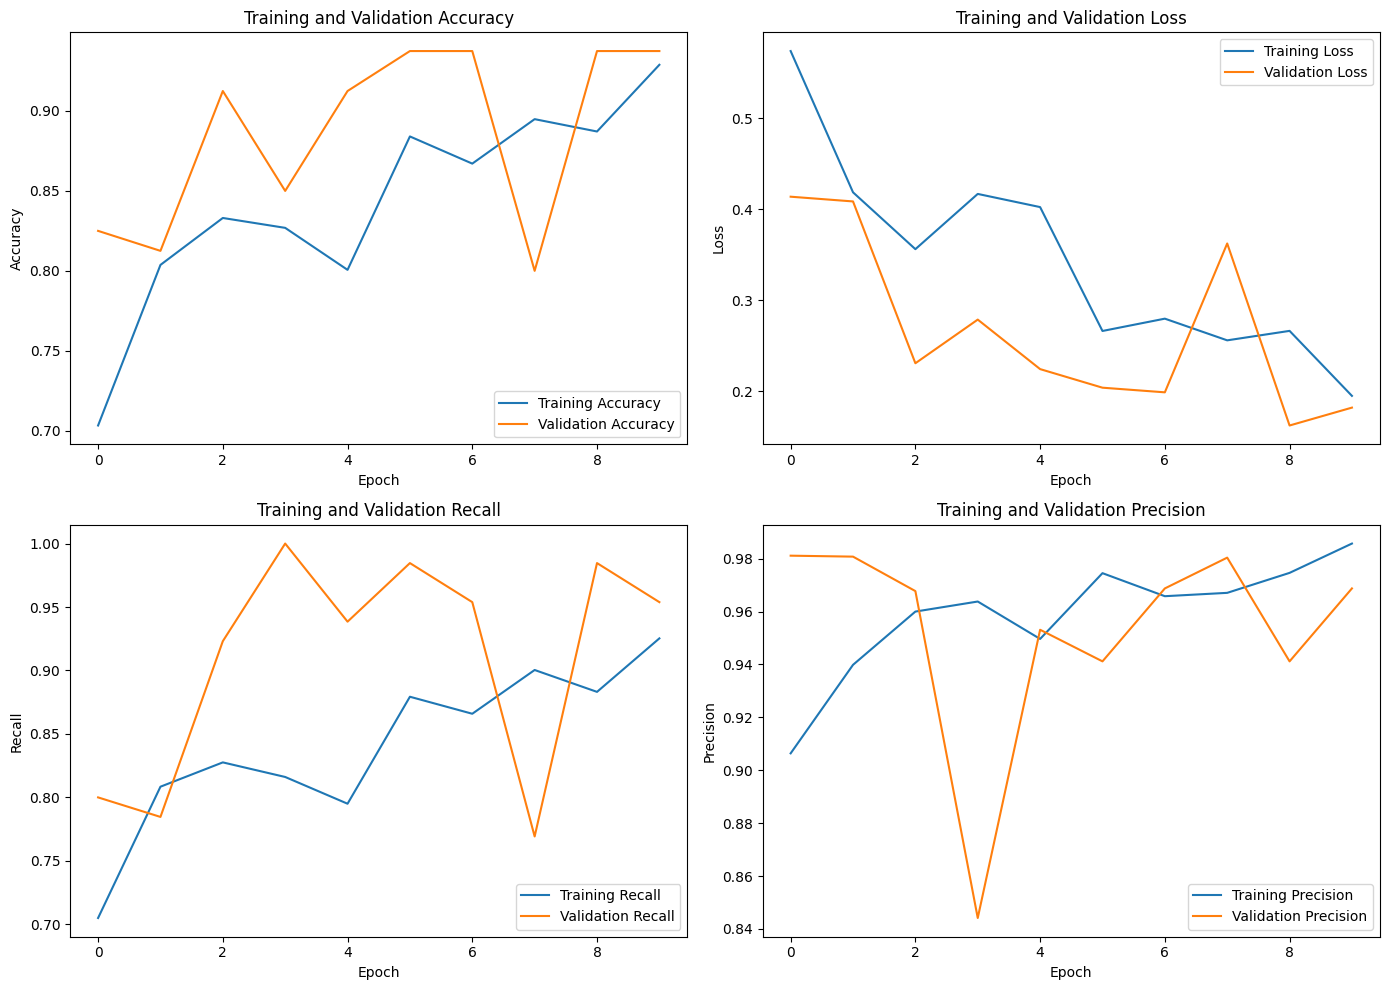

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
recall = history.history['recall']
val_recall = history.history['val_recall']
precision = history.history['precision']
val_precision = history.history['val_precision']

epochs_range = range(len(acc))
# --- 2. Create the 2x2 Grid of Plots ---
plt.figure(figsize=(14, 10))

# Plot 1: Accuracy
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot 2: Loss
plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot 3: Recall
plt.subplot(2, 2, 3)
plt.plot(epochs_range, recall, label='Training Recall')
plt.plot(epochs_range, val_recall, label='Validation Recall')
plt.legend(loc='lower right')
plt.title('Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')

# Plot 4: Precision
plt.subplot(2, 2, 4)
plt.plot(epochs_range, precision, label='Training Precision')
plt.plot(epochs_range, val_precision, label='Validation Precision')
plt.legend(loc='lower right')
plt.title('Training and Validation Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# --- Evaluate on the Test Set ---
print("\nEvaluating on test data...")

# Unpack all 6 values that model.evaluate() is returning
test_loss, test_accuracy, test_precision, test_recall, test_auc, test_f1 = model.evaluate(test_dataset)

# Print all the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")


Evaluating on test data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 9s/step - accuracy: 0.7928 - auc: 0.8621 - f1_score: 0.8142 - loss: 0.4922 - precision: 0.8155 - recall: 0.8666
Test Loss: 0.4069
Test Accuracy: 0.8434
Test Precision: 0.8955
Test Recall: 0.9091
Test AUC: 0.8659
Test F1 Score: 0.8859



Generating final classification report and confusion matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


/tmp/ipython-input-1921571576.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_true.append(int(labels.numpy()))



Classification Report (Target: 1 = Reciclable):
              precision    recall  f1-score   support

NoReciclable       0.62      0.59      0.61        17
  Reciclable       0.90      0.91      0.90        66

    accuracy                           0.84        83
   macro avg       0.76      0.75      0.75        83
weighted avg       0.84      0.84      0.84        83

Confusion Matrix:


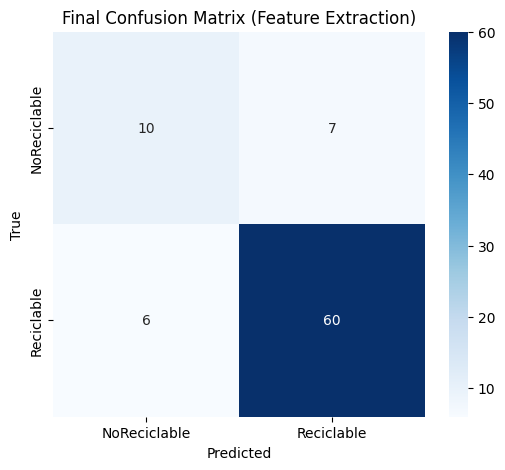

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nGenerating final classification report and confusion matrix...")

# --- 1. Get Predictions ---
# 'predictions' will be a 1D array of probabilities (e.g., [0.9, 0.1, 0.8])
predictions = model.predict(test_dataset)

# Convert probabilities to 0 or 1 by rounding at a 0.5 threshold
# .flatten() converts the (N, 1) shape to (N,)
y_pred = (predictions > 0.5).astype(int).flatten()

# --- 2. Get True Labels ---
y_true = []
# Loop through the test dataset
for images, labels in test_dataset.unbatch():
    # 'labels' is now a scalar (0.0 or 1.0), not a one-hot array
    # We just need to convert it to an integer
    y_true.append(int(labels.numpy()))

# Convert to a numpy array
y_true = np.array(y_true)

# --- 3. Generate Report and Matrix ---
# IMPORTANT: Make sure 'class_names' is your new list:
# e.g., class_names = ['Non-recyclable', 'Recyclable']
# You should get this from your Layer 1 train_dataset
print(f"\nClassification Report (Target: 1 = {class_names[1]}):")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5)) # Smaller size for a 2x2 matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix (Feature Extraction)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_binary_roc_curve(y_true_labels, y_pred_probs, positive_class_name):
    """
    Plots the ROC curve for a binary classification model.

    Args:
        y_true_labels (array-like): Ground truth labels (0s and 1s).
        y_pred_probs (array-like): Model's raw probability predictions (1D array).
        positive_class_name (str): The name of the positive class (e.g., "Recyclable").
    """

    # Calculate the ROC curve
    # 'y_true_labels' and 'y_pred_probs' are both 1D arrays
    fpr, tpr, _ = roc_curve(y_true_labels, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label='ROC curve for class "{0}" (area = {1:0.2f})'
             ''.format(positive_class_name, roc_auc))

    # Plot the "random guess" line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

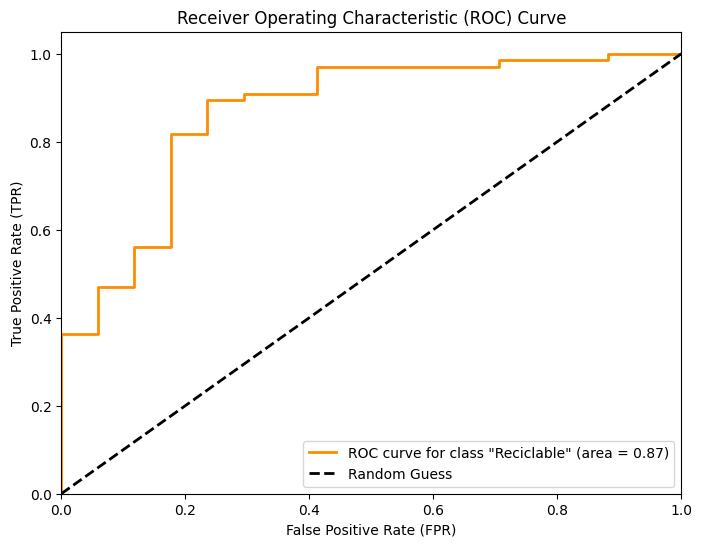

In [ ]:
plot_binary_roc_curve(y_true, predictions.flatten(), class_names[1])

## Save base InceptionV3 model v1.0

In [ ]:
model_save_path = '/content/drive/MyDrive/Tesis/Modelo/Layer 1/InceptionV3/binary_inceptionv3_model_1.keras'

In [ ]:
# --- 1. Save Your Model ---

print(f"Saving model to {model_save_path} ...")

# Save the entire model
model.save(model_save_path)

print("Model saved successfully! 💾")

Saving model to /content/drive/MyDrive/Tesis/Modelo/Layer 1/InceptionV3/binary_inceptionv3_model_1.keras ...
Model saved successfully! 💾


Load it back again:

In [ ]:
# --- 2. Load it ---
# Just define and load your data, then run:

from tensorflow.keras.models import load_model

print("Loading model from disk...")
model = load_model(model_save_path, compile=False)
print("Model loaded.")

model.summary()

Loading model from disk...
Model loaded.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inceptionv3_base (Functional)   │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

##Step 7: Fine-Tuning Configuration

In [ ]:
#Get the base model
base_model = model.get_layer('inceptionv3_base')

#Unfreeze base model
base_model.trainable = True

#Recompile model with a very low learning rate
#using 1e-5 (0.00001)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        F1Score(name='f1_score')
    ]
)
print('\n Model now in fine-tuning mode')
model.summary()


 Model now in fine-tuning mode


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inceptionv3_base (Functional)   │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 22,030,753 (84.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
# --- Calculate Class Weights ---
# Class 0: Non-recyclable (157 images)
# Class 1: Recyclable (653 images)
# Total: 810 images

weight_for_0 = (1 / 157) * (810 / 2.0)
weight_for_1 = (1 / 653) * (810 / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for class 0 (Non-recyclable): {weight_for_0:.2f}")
print(f"Weight for class 1 (Recyclable): {weight_for_1:.2f}")

Weight for class 0 (Non-recyclable): 2.58
Weight for class 1 (Recyclable): 0.62


##Step 8: Fine-Tuning

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

FINE_TUNE_EPOCHS = 10
# Already trained epochs
initial_epochs = EPOCHS
# How many epochs in total
total_epochs = initial_epochs + FINE_TUNE_EPOCHS

# 1. Early Stopping
# 'patience=3' -> it will stop if val_loss doesn't improve for 3 epochs
# 'restore_best_weights=True' -> it will return the model from the best epoch
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print("Starting fine-tuning...")

# 2. Continue training the model
history_fine_tune = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=initial_epochs, # Start counting from 10
    validation_data=val_dataset,
    class_weight=class_weight,
    callbacks=[early_stopping] # Add the early stopping callback
)

print("Fine-tuning complete.")

Starting fine-tuning...
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7084 - auc: 0.9064 - f1_score: 0.8981 - loss: 0.4475 - precision: 0.9864 - recall: 0.6514 - val_accuracy: 0.9250 - val_auc: 0.9682 - val_f1_score: 0.8966 - val_loss: 0.1958 - val_precision: 0.9275 - val_recall: 0.9846
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.8037 - auc: 0.9326 - f1_score: 0.8815 - loss: 0.3514 - precision: 0.9560 - recall: 0.7890 - val_accuracy: 0.9125 - val_auc: 0.9692 - val_f1_score: 0.8966 - val_loss: 0.2213 - val_precision: 0.9028 - val_recall: 1.0000
Epoch 13/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8528 - auc: 0.9569 - f1_score: 0.8922 - loss: 0.2781 - precision: 0.9725 - recall: 0.8412 - val_accuracy: 0.9250 - val_auc: 0.9723 - val_f1_score: 0.8966 - val_loss: 0.2006 - val_precision: 0.9155 - val_recall: 1.0000
Epoch 14/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8882 - auc: 0.9773 - f1_score: 0.8960 - loss: 0.2204 - precisi

### Evaluating Final Fine-Tune model

In [ ]:
import matplotlib.pyplot as plt

# --- Evaluate on the Test Set ---
print("\nEvaluating on test data...")

# Unpack all 6 values that model.evaluate() is returning
test_loss, test_accuracy, test_precision, test_recall, test_auc, test_f1 = model.evaluate(test_dataset)

# Print all the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1 Score (Macro): {test_f1:.4f}")


Evaluating on test data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8935 - auc: 0.8752 - f1_score: 0.8142 - loss: 0.4236 - precision: 0.8740 - recall: 0.9704
Test Loss: 0.3152
Test Accuracy: 0.9277
Test Precision: 0.9286
Test Recall: 0.9848
Test AUC: 0.8703
Test F1 Score (Macro): 0.8859



Generating final classification report and confusion matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


/tmp/ipython-input-744431305.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_true.append(int(labels.numpy()))



Classification Report (Target: 1 = Reciclable):
              precision    recall  f1-score   support

NoReciclable       0.92      0.71      0.80        17
  Reciclable       0.93      0.98      0.96        66

    accuracy                           0.93        83
   macro avg       0.93      0.85      0.88        83
weighted avg       0.93      0.93      0.92        83

Confusion Matrix:


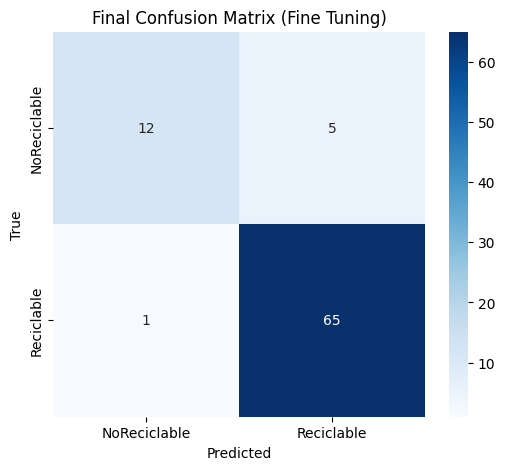

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nGenerating final classification report and confusion matrix...")

# --- 1. Get Predictions ---
# 'predictions' will be a 1D array of probabilities (e.g., [0.9, 0.1, 0.8])
predictions = model.predict(test_dataset)

# Convert probabilities to 0 or 1 by rounding at a 0.5 threshold
# .flatten() converts the (N, 1) shape to (N,)
y_pred = (predictions > 0.5).astype(int).flatten()

# --- 2. Get True Labels ---
y_true = []
# Loop through the test dataset
for images, labels in test_dataset.unbatch():
    # 'labels' is now a scalar (0.0 or 1.0), not a one-hot array
    # We just need to convert it to an integer
    y_true.append(int(labels.numpy()))

# Convert to a numpy array
y_true = np.array(y_true)

# --- 3. Generate Report and Matrix ---
# IMPORTANT: Make sure 'class_names' is your new list:
# e.g., class_names = ['Non-recyclable', 'Recyclable']
# You should get this from your Layer 1 train_dataset
print(f"\nClassification Report (Target: 1 = {class_names[1]}):")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5)) # Smaller size for a 2x2 matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix (Fine Tuning)')
plt.show()

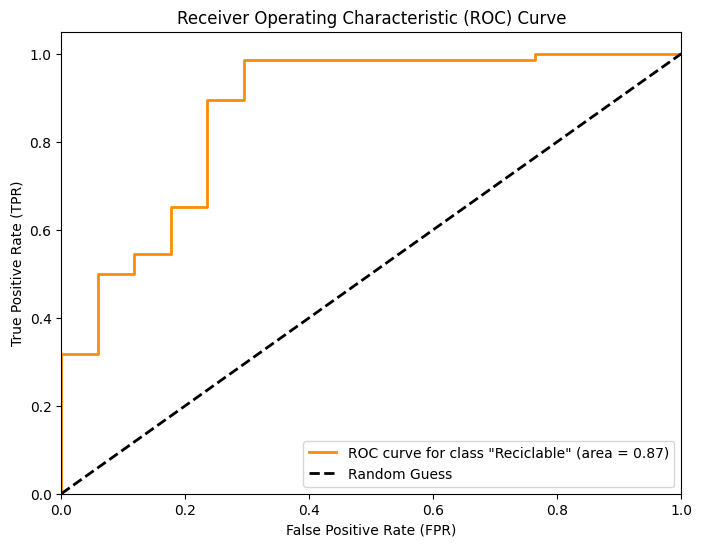

In [ ]:
plot_binary_roc_curve(y_true, predictions.flatten(), class_names[1])

Saving for documentation

In [ ]:
save_model_finetune = '/content/drive/MyDrive/Tesis/Modelo/Layer 1/InceptionV3/binary_inceptionv3_model_ft_1.keras'
# --- 1. Save Your Model ---

print(f"Saving model to {save_model_finetune} ...")

# Save the entire model
model.save(save_model_finetune)

print("Model saved successfully! 💾")

Saving model to /content/drive/MyDrive/Tesis/Modelo/Layer 1/InceptionV3/binary_inceptionv3_model_ft_1.keras ...
Model saved successfully! 💾
